# Task 4 — Model Creation

Three models are built in this notebook:
1. **Facial Recognition Model** — identifies which group member a face belongs to
2. **Voiceprint Verification Model** — identifies which member a voice belongs to
3. **Product Recommendation Model** — predicts the product category a customer would purchase

Each model is evaluated with **Accuracy**, **F1-Score (weighted)**, and **Log Loss**.

In [19]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 110

SEED = 42
MODELS_DIR = 'saved_models'
os.makedirs(MODELS_DIR, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## Load Datasets

In [20]:
image_df   = pd.read_csv('data/processed/image_features.csv')
audio_df   = pd.read_csv('../features/audio_features.csv')
product_df = pd.read_csv('data/processed/merged_dataset.csv')

print(f'Image features  : {image_df.shape}')
print(f'Audio features  : {audio_df.shape}')
print(f'Product dataset : {product_df.shape}')

Image features  : (108, 15)
Audio features  : (32, 37)
Product dataset : (213, 21)


---
## 1. Facial Recognition Model

**Input:** Image features (colour stats, edge density, LBP texture)  
**Target:** `member` — identify which group member the face belongs to  
**Dataset:** 108 rows (4 members × 3 expressions × 9 augmentation versions)

In [21]:
# --- Prepare features ---
FACE_DROP = ['member', 'expression', 'augmentation']
X_face     = image_df.drop(columns=FACE_DROP)
y_face_raw = image_df['member']

face_le = LabelEncoder()
y_face  = face_le.fit_transform(y_face_raw)

print('Classes:', face_le.classes_)
print('Feature shape:', X_face.shape)
print('\nClass distribution:')
print(pd.Series(y_face_raw).value_counts())

Classes: ['David' 'Kelvin' 'Michael Kimani' 'Samuel']
Feature shape: (108, 12)

Class distribution:
member
Michael Kimani    27
David             27
Kelvin            27
Samuel            27
Name: count, dtype: int64


In [22]:
# --- Train / Test split (stratified) ---
X_face_train, X_face_test, y_face_train, y_face_test = train_test_split(
    X_face, y_face, test_size=0.2, random_state=SEED, stratify=y_face
)
print(f'Train: {X_face_train.shape[0]} | Test: {X_face_test.shape[0]}')

Train: 86 | Test: 22


In [23]:
# --- Train models ---
face_rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
face_rf.fit(X_face_train, y_face_train)

face_lr = LogisticRegression(max_iter=1000, random_state=SEED)
face_lr.fit(X_face_train, y_face_train)

print('Facial recognition models trained.')

Facial recognition models trained.


In [24]:
# --- Evaluate ---
def evaluate(name, model, X_test, y_test, le):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    loss = log_loss(y_test, y_proba)
    print(f'\n{name}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  Log Loss  : {loss:.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    return {'model': name, 'accuracy': acc, 'f1': f1, 'log_loss': loss}

face_results = []
face_results.append(evaluate('Random Forest',      face_rf, X_face_test, y_face_test, face_le))
face_results.append(evaluate('Logistic Regression', face_lr, X_face_test, y_face_test, face_le))


Random Forest
  Accuracy  : 0.9545
  F1 Score  : 0.9542
  Log Loss  : 0.1708
                precision    recall  f1-score   support

         David       1.00      0.83      0.91         6
        Kelvin       1.00      1.00      1.00         5
Michael Kimani       0.86      1.00      0.92         6
        Samuel       1.00      1.00      1.00         5

      accuracy                           0.95        22
     macro avg       0.96      0.96      0.96        22
  weighted avg       0.96      0.95      0.95        22


Logistic Regression
  Accuracy  : 0.9545
  F1 Score  : 0.9545
  Log Loss  : 0.2624
                precision    recall  f1-score   support

         David       1.00      0.83      0.91         6
        Kelvin       0.83      1.00      0.91         5
Michael Kimani       1.00      1.00      1.00         6
        Samuel       1.00      1.00      1.00         5

      accuracy                           0.95        22
     macro avg       0.96      0.96      0.95    

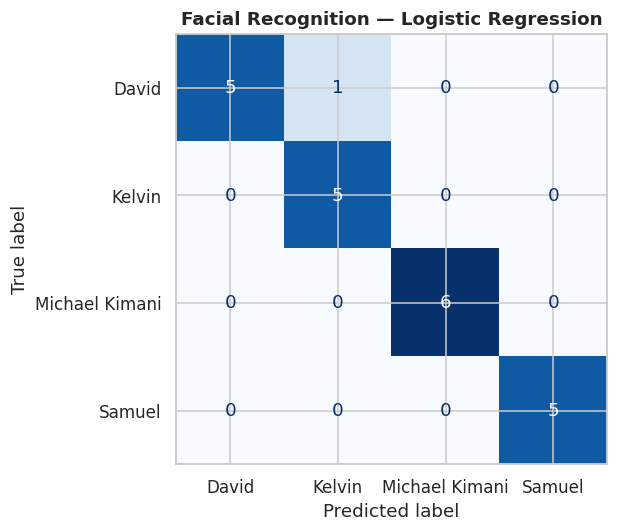

Best facial recognition model: Logistic Regression


In [25]:
# --- Confusion matrix for best model ---
best_face_idx   = 0 if face_results[0]['f1'] >= face_results[1]['f1'] else 1
best_face_model = [face_rf, face_lr][best_face_idx]
best_face_name  = face_results[best_face_idx]['model']

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    best_face_model, X_face_test, y_face_test,
    display_labels=face_le.classes_, ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Facial Recognition — {best_face_name}', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Best facial recognition model: {best_face_name}')

In [26]:
# --- Save model + encoder ---
joblib.dump(best_face_model, f'{MODELS_DIR}/facial_recognition_model.pkl')
joblib.dump(face_le,         f'{MODELS_DIR}/face_label_encoder.pkl')
print(f'Saved: {MODELS_DIR}/facial_recognition_model.pkl')

Saved: saved_models/facial_recognition_model.pkl


---
## 2. Voiceprint Verification Model

**Input:** Audio features (MFCCs, spectral roll-off, energy RMS, ZCR)  
**Target:** `member` — verify which member's voice it is  
**Dataset:** 32 rows — small, so **Stratified K-Fold cross-validation** is used instead of a single split

In [27]:
# --- Prepare features ---
AUDIO_DROP = ['member', 'phrase_label', 'sample_type', 'file_name']
X_audio     = audio_df.drop(columns=AUDIO_DROP)
y_audio_raw = audio_df['member']

voice_le = LabelEncoder()
y_audio  = voice_le.fit_transform(y_audio_raw)

# Scale features (important for audio)
scaler = StandardScaler()
X_audio_scaled = scaler.fit_transform(X_audio)

print('Classes:', voice_le.classes_)
print('Feature shape:', X_audio.shape)
print('\nClass distribution:')
print(pd.Series(y_audio_raw).value_counts())

Classes: ['David' 'Kelvin' 'Michael Kimani' 'Samuel']
Feature shape: (32, 33)

Class distribution:
member
David             8
Kelvin            8
Michael Kimani    8
Samuel            8
Name: count, dtype: int64


In [28]:
# --- Stratified K-Fold CV (n_splits=4 gives 8 test / 24 train per fold) ---
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)

voice_rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
voice_lr = LogisticRegression(max_iter=1000, random_state=SEED)

def cv_evaluate(name, model, X, y, le, cv):
    y_pred  = cross_val_predict(model, X, y, cv=cv, method='predict')
    y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')
    acc  = accuracy_score(y, y_pred)
    f1   = f1_score(y, y_pred, average='weighted')
    loss = log_loss(y, y_proba)
    print(f'\n{name} (4-Fold CV)')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  Log Loss  : {loss:.4f}')
    print(classification_report(y, y_pred, target_names=le.classes_))
    return {'model': name, 'accuracy': acc, 'f1': f1, 'log_loss': loss}

voice_results = []
voice_results.append(cv_evaluate('Random Forest',       voice_rf, X_audio_scaled, y_audio, voice_le, skf))
voice_results.append(cv_evaluate('Logistic Regression', voice_lr, X_audio_scaled, y_audio, voice_le, skf))


Random Forest (4-Fold CV)
  Accuracy  : 1.0000
  F1 Score  : 1.0000
  Log Loss  : 0.3961
                precision    recall  f1-score   support

         David       1.00      1.00      1.00         8
        Kelvin       1.00      1.00      1.00         8
Michael Kimani       1.00      1.00      1.00         8
        Samuel       1.00      1.00      1.00         8

      accuracy                           1.00        32
     macro avg       1.00      1.00      1.00        32
  weighted avg       1.00      1.00      1.00        32


Logistic Regression (4-Fold CV)
  Accuracy  : 1.0000
  F1 Score  : 1.0000
  Log Loss  : 0.0648
                precision    recall  f1-score   support

         David       1.00      1.00      1.00         8
        Kelvin       1.00      1.00      1.00         8
Michael Kimani       1.00      1.00      1.00         8
        Samuel       1.00      1.00      1.00         8

      accuracy                           1.00        32
     macro avg       1.00

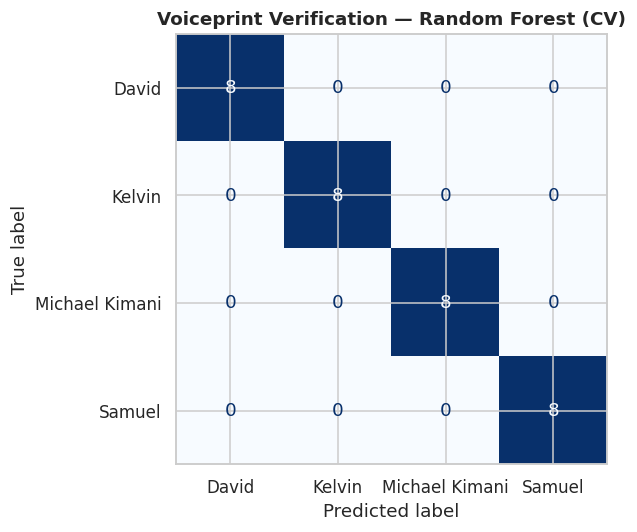

Best voiceprint model: Random Forest


In [29]:
# --- Confusion matrix (CV predictions) ---
best_voice_idx   = 0 if voice_results[0]['f1'] >= voice_results[1]['f1'] else 1
best_voice_model = [voice_rf, voice_lr][best_voice_idx]
best_voice_name  = voice_results[best_voice_idx]['model']

y_voice_pred_cv = cross_val_predict(best_voice_model, X_audio_scaled, y_audio, cv=skf)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_audio, y_voice_pred_cv,
    display_labels=voice_le.classes_, ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Voiceprint Verification — {best_voice_name} (CV)', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Best voiceprint model: {best_voice_name}')

In [30]:
# --- Fit final model on full dataset & save ---
best_voice_model.fit(X_audio_scaled, y_audio)

joblib.dump(best_voice_model, f'{MODELS_DIR}/voiceprint_model.pkl')
joblib.dump(voice_le,         f'{MODELS_DIR}/voice_label_encoder.pkl')
joblib.dump(scaler,           f'{MODELS_DIR}/audio_scaler.pkl')
print(f'Saved: {MODELS_DIR}/voiceprint_model.pkl')

Saved: saved_models/voiceprint_model.pkl


---
## 3. Product Recommendation Model

**Input:** Merged tabular features (engagement, purchase history, platform, sentiment, etc.)  
**Target:** `product_category` — predict what product the customer would buy  
**Dataset:** 213 rows, 5 categories

In [31]:
# --- Prepare features (drop IDs, raw date, redundant text columns) ---
PRODUCT_DROP = [
    'customer_id_new', 'customer_id', 'customer_id_legacy',
    'transaction_id', 'purchase_date',
    'social_media_platform', 'review_sentiment',
    'product_category'
]
X_product = product_df.drop(columns=PRODUCT_DROP)

# Convert boolean platform columns to int
bool_cols = X_product.select_dtypes(include='bool').columns
X_product[bool_cols] = X_product[bool_cols].astype(int)

y_product_raw = product_df['product_category']
product_le    = LabelEncoder()
y_product     = product_le.fit_transform(y_product_raw)

print('Classes:', product_le.classes_)
print('Feature shape:', X_product.shape)
print('\nClass distribution:')
print(pd.Series(y_product_raw).value_counts())

Classes: ['Books' 'Clothing' 'Electronics' 'Groceries' 'Sports']
Feature shape: (213, 13)

Class distribution:
product_category
Sports         59
Electronics    45
Groceries      38
Books          38
Clothing       33
Name: count, dtype: int64


In [32]:
# --- Train / Test split ---
X_prod_train, X_prod_test, y_prod_train, y_prod_test = train_test_split(
    X_product, y_product, test_size=0.2, random_state=SEED, stratify=y_product
)
print(f'Train: {X_prod_train.shape[0]} | Test: {X_prod_test.shape[0]}')

Train: 170 | Test: 43


In [33]:
# --- Train models ---
prod_rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
prod_rf.fit(X_prod_train, y_prod_train)

prod_lr = LogisticRegression(max_iter=1000, random_state=SEED)
prod_lr.fit(X_prod_train, y_prod_train)

print('Product recommendation models trained.')

Product recommendation models trained.


In [34]:
# --- Evaluate ---
prod_results = []
prod_results.append(evaluate('Random Forest',       prod_rf, X_prod_test, y_prod_test, product_le))
prod_results.append(evaluate('Logistic Regression', prod_lr, X_prod_test, y_prod_test, product_le))


Random Forest
  Accuracy  : 0.6047
  F1 Score  : 0.5985
  Log Loss  : 1.0230
              precision    recall  f1-score   support

       Books       0.60      0.75      0.67         8
    Clothing       0.50      0.33      0.40         6
 Electronics       0.55      0.67      0.60         9
   Groceries       0.80      0.50      0.62         8
      Sports       0.62      0.67      0.64        12

    accuracy                           0.60        43
   macro avg       0.61      0.58      0.58        43
weighted avg       0.62      0.60      0.60        43


Logistic Regression
  Accuracy  : 0.3023
  F1 Score  : 0.2803
  Log Loss  : 1.6162
              precision    recall  f1-score   support

       Books       0.00      0.00      0.00         8
    Clothing       0.29      0.33      0.31         6
 Electronics       0.29      0.44      0.35         9
   Groceries       0.40      0.25      0.31         8
      Sports       0.36      0.42      0.38        12

    accuracy           

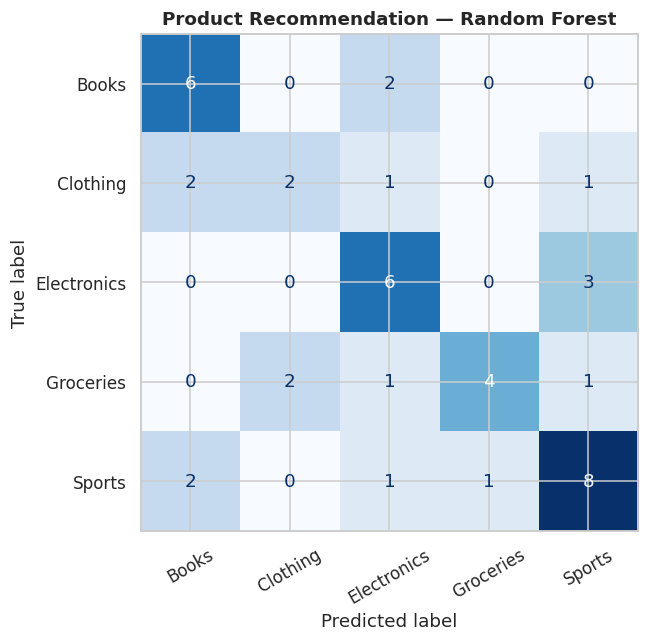

Best product recommendation model: Random Forest


In [35]:
# --- Confusion matrix for best model ---
best_prod_idx   = 0 if prod_results[0]['f1'] >= prod_results[1]['f1'] else 1
best_prod_model = [prod_rf, prod_lr][best_prod_idx]
best_prod_name  = prod_results[best_prod_idx]['model']

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    best_prod_model, X_prod_test, y_prod_test,
    display_labels=product_le.classes_, ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Product Recommendation — {best_prod_name}', fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print(f'Best product recommendation model: {best_prod_name}')

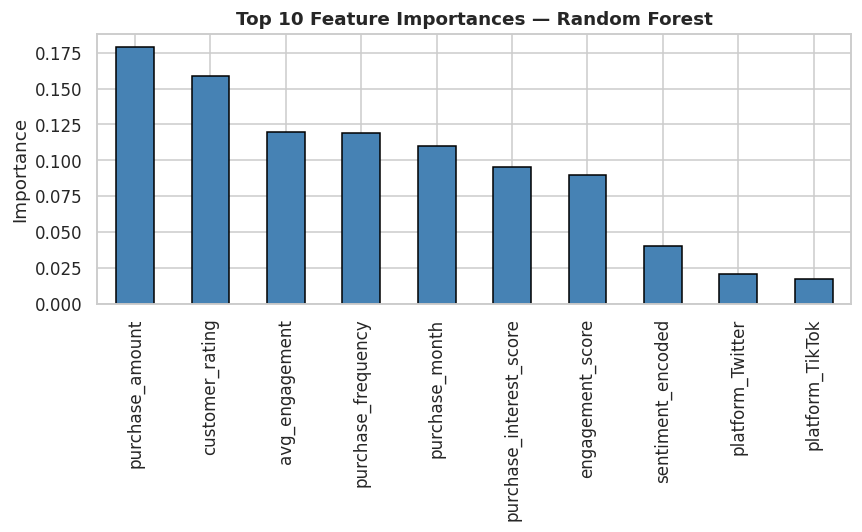

In [36]:
# --- Feature importance (works for both RF and Logistic Regression) ---
if hasattr(best_prod_model, 'feature_importances_'):
    importances = pd.Series(best_prod_model.feature_importances_, index=X_product.columns)
else:
    importances = pd.Series(np.abs(best_prod_model.coef_).mean(axis=0), index=X_product.columns)

importances = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.bar(ax=ax, color='steelblue', edgecolor='black')
ax.set_title(f'Top 10 Feature Importances — {best_prod_name}', fontweight='bold')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()

In [37]:
# --- Save model + encoder ---
joblib.dump(best_prod_model,          f'{MODELS_DIR}/product_recommendation_model.pkl')
joblib.dump(product_le,               f'{MODELS_DIR}/product_label_encoder.pkl')
joblib.dump(list(X_product.columns),  f'{MODELS_DIR}/product_feature_columns.pkl')
print(f'Saved: {MODELS_DIR}/product_recommendation_model.pkl')

Saved: saved_models/product_recommendation_model.pkl


---
## 4. Metrics Summary

In [38]:
best_face_result  = face_results[best_face_idx]
best_voice_result = voice_results[best_voice_idx]
best_prod_result  = prod_results[best_prod_idx]

summary = pd.DataFrame([
    {'Task': 'Facial Recognition',    'Best Model': best_face_name,  **{k: best_face_result[k]  for k in ['accuracy','f1','log_loss']}},
    {'Task': 'Voiceprint Verification','Best Model': best_voice_name, **{k: best_voice_result[k] for k in ['accuracy','f1','log_loss']}},
    {'Task': 'Product Recommendation', 'Best Model': best_prod_name,  **{k: best_prod_result[k]  for k in ['accuracy','f1','log_loss']}},
]).set_index('Task')

summary[['accuracy', 'f1', 'log_loss']] = summary[['accuracy', 'f1', 'log_loss']].round(4)
summary.columns = ['Best Model', 'Accuracy', 'F1 Score', 'Log Loss']
display(summary)

,Best Model,Accuracy,F1 Score,Log Loss
Task,,,,
Facial Recognition,Logistic Regression,0.9545,0.9545,0.2624
Voiceprint Verification,Random Forest,1.0000,1.0000,0.3961
Product Recommendation,Random Forest,0.6047,0.5985,1.0230


---
## 5. System Demonstration

Simulates the full authentication and prediction flow:

1. User submits a **face image** → Facial Recognition checks if they are a known member
2. If recognized → User submits **voice** → Voiceprint model verifies the identity matches
3. If voice approved → **Product Recommendation** runs and displays the prediction

An **unauthorized attempt** (face/voice mismatch) is also simulated.

In [39]:
# --- Load saved models ---
face_model  = joblib.load(f'{MODELS_DIR}/facial_recognition_model.pkl')
face_enc    = joblib.load(f'{MODELS_DIR}/face_label_encoder.pkl')
voice_model = joblib.load(f'{MODELS_DIR}/voiceprint_model.pkl')
voice_enc   = joblib.load(f'{MODELS_DIR}/voice_label_encoder.pkl')
audio_scl   = joblib.load(f'{MODELS_DIR}/audio_scaler.pkl')
prod_model  = joblib.load(f'{MODELS_DIR}/product_recommendation_model.pkl')
prod_enc    = joblib.load(f'{MODELS_DIR}/product_label_encoder.pkl')
prod_cols   = joblib.load(f'{MODELS_DIR}/product_feature_columns.pkl')

print('All models loaded.')

All models loaded.


In [40]:
# --- Pipeline helper ---
FACE_FEATURES  = [c for c in image_df.columns  if c not in ['member', 'expression', 'augmentation']]
AUDIO_FEATURES = [c for c in audio_df.columns  if c not in ['member', 'phrase_label', 'sample_type', 'file_name']]

def run_pipeline(face_row, audio_row, product_row, label='Simulation'):
    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'{"="*55}')

    # Step 1 — Face recognition
    face_input = face_row[FACE_FEATURES].values.reshape(1, -1)
    face_pred  = face_model.predict(face_input)[0]
    face_proba = face_model.predict_proba(face_input).max()
    face_name  = face_enc.inverse_transform([face_pred])[0]
    print(f'\n[STEP 1] Face Recognition')
    print(f'  Identified as : {face_name} (confidence: {face_proba:.1%})')
    print('  Face recognized. Proceeding to voice verification...')

    # Step 2 — Voice verification
    audio_input = audio_scl.transform(audio_row[AUDIO_FEATURES].values.reshape(1, -1))
    voice_pred  = voice_model.predict(audio_input)[0]
    voice_proba = voice_model.predict_proba(audio_input).max()
    voice_name  = voice_enc.inverse_transform([voice_pred])[0]
    print(f'\n[STEP 2] Voice Verification')
    print(f'  Voice identified as : {voice_name} (confidence: {voice_proba:.1%})')

    if voice_name != face_name:
        print(f'  ACCESS DENIED — voice ({voice_name}) does not match face ({face_name}).')
        return
    print('  Voice approved. Running product prediction...')

    # Step 3 — Product recommendation
    prod_input = pd.DataFrame([product_row])[prod_cols].values
    prod_pred  = prod_model.predict(prod_input)[0]
    prod_proba = prod_model.predict_proba(prod_input).max()
    prod_name  = prod_enc.inverse_transform([prod_pred])[0]
    print(f'\n[STEP 3] Product Recommendation')
    print(f'  Predicted product : {prod_name} (confidence: {prod_proba:.1%})')
    print(f'\n  TRANSACTION APPROVED for {face_name} — recommended: {prod_name}')

print('Pipeline ready.')

Pipeline ready.


In [41]:
# --- SIMULATION 1: Authorized user (David) ---
auth_member   = 'David'
face_sample   = image_df[(image_df['member'] == auth_member) & (image_df['augmentation'] == 'original')].iloc[0]
audio_sample  = audio_df[(audio_df['member'] == auth_member) & (audio_df['sample_type']  == 'original')].iloc[0]
product_sample = product_df[prod_cols].iloc[0]

run_pipeline(face_sample, audio_sample, product_sample,
             label=f'Authorized User — {auth_member}')


  Authorized User — David

[STEP 1] Face Recognition
  Identified as : David (confidence: 99.9%)
  Face recognized. Proceeding to voice verification...

[STEP 2] Voice Verification
  Voice identified as : David (confidence: 94.5%)
  Voice approved. Running product prediction...

[STEP 3] Product Recommendation
  Predicted product : Groceries (confidence: 65.5%)

  TRANSACTION APPROVED for David — recommended: Groceries


In [42]:
# --- SIMULATION 2: Unauthorized attempt (face/voice mismatch) ---
face_unauth  = image_df[(image_df['member'] == 'Kelvin') & (image_df['augmentation'] == 'original')].iloc[0]
audio_unauth = audio_df[(audio_df['member'] == 'Samuel') & (audio_df['sample_type']  == 'original')].iloc[0]
prod_unauth  = product_df[prod_cols].iloc[0]

run_pipeline(face_unauth, audio_unauth, prod_unauth,
             label='Unauthorized Attempt — face/voice mismatch (Kelvin face, Samuel voice)')


  Unauthorized Attempt — face/voice mismatch (Kelvin face, Samuel voice)

[STEP 1] Face Recognition
  Identified as : Kelvin (confidence: 100.0%)
  Face recognized. Proceeding to voice verification...

[STEP 2] Voice Verification
  Voice identified as : Samuel (confidence: 93.0%)
  ACCESS DENIED — voice (Samuel) does not match face (Kelvin).


In [43]:
# --- SIMULATION 3: Full authorized flow for all four members ---
for member in ['David', 'Kelvin', 'Michael Kimani', 'Samuel']:
    f_row = image_df[(image_df['member'] == member) & (image_df['augmentation'] == 'original')].iloc[0]
    a_row = audio_df[(audio_df['member'] == member) & (audio_df['sample_type']  == 'original')].iloc[0]
    p_row = product_df[prod_cols].sample(1, random_state=SEED).iloc[0]
    run_pipeline(f_row, a_row, p_row, label=f'Full Flow — {member}')


  Full Flow — David

[STEP 1] Face Recognition
  Identified as : David (confidence: 99.9%)
  Face recognized. Proceeding to voice verification...



[STEP 2] Voice Verification
  Voice identified as : David (confidence: 94.5%)
  Voice approved. Running product prediction...

[STEP 3] Product Recommendation
  Predicted product : Groceries (confidence: 73.5%)

  TRANSACTION APPROVED for David — recommended: Groceries

  Full Flow — Kelvin

[STEP 1] Face Recognition
  Identified as : Kelvin (confidence: 100.0%)
  Face recognized. Proceeding to voice verification...

[STEP 2] Voice Verification
  Voice identified as : Kelvin (confidence: 95.0%)
  Voice approved. Running product prediction...

[STEP 3] Product Recommendation
  Predicted product : Groceries (confidence: 73.5%)

  TRANSACTION APPROVED for Kelvin — recommended: Groceries

  Full Flow — Michael Kimani

[STEP 1] Face Recognition
  Identified as : Michael Kimani (confidence: 100.0%)
  Face recognized. Proceeding to voice verification...

[STEP 2] Voice Verification
  Voice identified as : Michael Kimani (confidence: 94.5%)
  Voice approved. Running product prediction...

[ST